In [1]:
%load_ext autoreload
%autoreload 2

from avito_orientation.dataset import OrientationDataset

In [2]:
from datasets import load_dataset

train_ds = load_dataset(
    "MiXaiLL76/TextOCR_OCR",
    split="train",
)

val_ds = load_dataset(
    "MiXaiLL76/ICDAR2015_OCR",
    split="train",
)

print(train_ds)
print(val_ds)

Dataset({
    features: ['image', 'text'],
    num_rows: 91373
})
Dataset({
    features: ['image', 'text'],
    num_rows: 4468
})


In [3]:
print(train_ds.features)
print(val_ds.features)

print(train_ds[0])
print(val_ds[0])

print(train_ds)
print(val_ds)

{'image': Image(mode=None, decode=True), 'text': Value('string')}
{'image': Image(mode=None, decode=True), 'text': Value('string')}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=197x33 at 0x76560E91D910>, 'text': 'Performance'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=88x13 at 0x76560E91CE60>, 'text': 'Genaxis Theatre'}
Dataset({
    features: ['image', 'text'],
    num_rows: 91373
})
Dataset({
    features: ['image', 'text'],
    num_rows: 4468
})


In [4]:
from torch.utils.data import DataLoader

from avito_orientation.dataset import OrientationDataset

train_data = OrientationDataset(
    train_ds,
    train=True,
)

val_data = OrientationDataset(
    val_ds,
    train=False,
)

print(len(train_data))
print(len(val_data))

loader = DataLoader(
    train_data,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

images, labels = next(iter(loader))

print(images.shape)
print(labels)
print(labels.mean())

91373
8936
torch.Size([16, 3, 64, 768])
tensor([1., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1.])
tensor(0.6250)


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def show_augmentations(dataset, augment, indices=None, n_aug=5):
    if indices is None:
        indices = [10, 100, 1000, 5000]

    fig, axes = plt.subplots(
        len(indices),
        n_aug + 1,
        figsize=(18, 3 * len(indices)),
    )

    for row, idx in enumerate(indices):
        image = dataset[idx]["image"].convert("RGB")
        image_np = np.array(image)

        # Original
        axes[row, 0].imshow(image)
        axes[row, 0].set_title(
            f"Original\n{image.size[0]}×{image.size[1]}"
        )
        axes[row, 0].axis("off")

        # Несколько независимых применений pipeline
        for col in range(1, n_aug + 1):
            augmented = augment(image=image_np)["image"]

            axes[row, col].imshow(augmented)
            axes[row, col].set_title(f"Aug #{col}")
            axes[row, col].axis("off")

    plt.tight_layout()

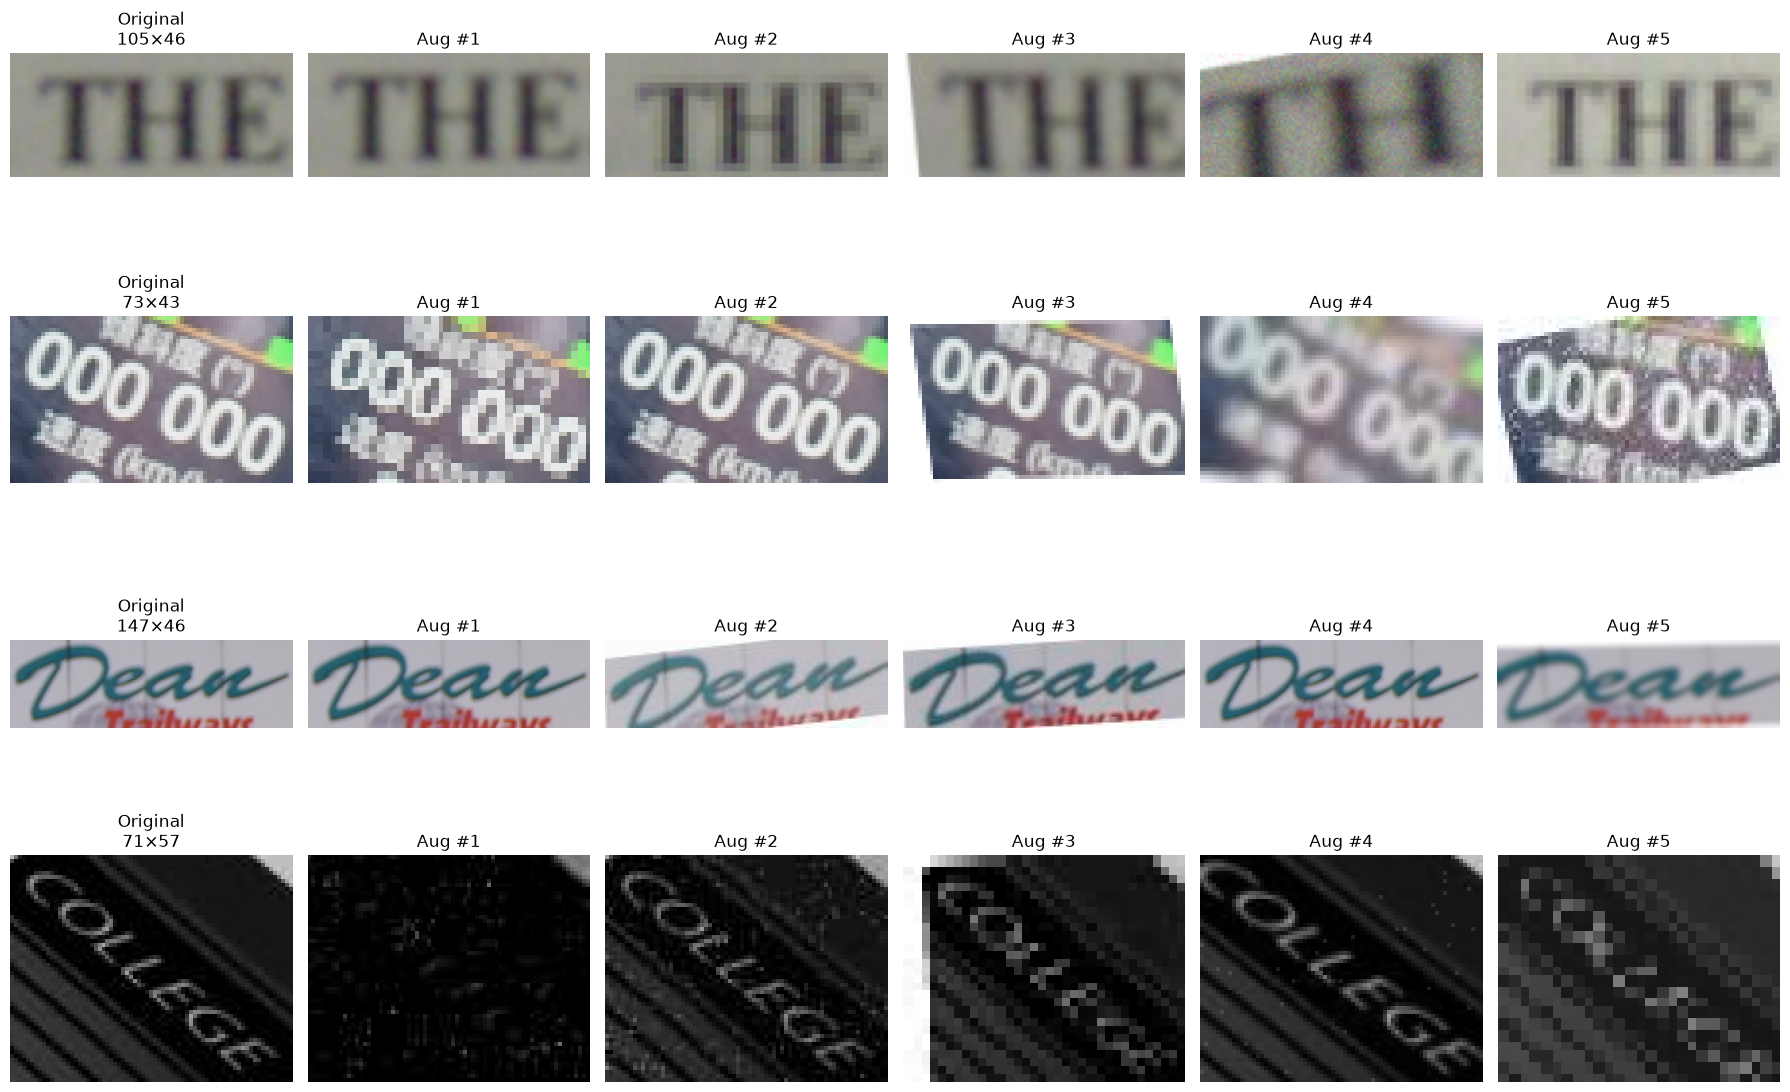

In [6]:
show_augmentations(
    train_ds,
    train_data.augment,
    indices=[10, 100, 1000, 5000],
    n_aug=5,
)

In [7]:
import importlib
import avito_orientation.dataset as ds

ds = importlib.reload(ds)

train_data = ds.OrientationDataset(
    train_ds,
    train=True,
)

In [8]:
from avito_orientation.dataset import OrientationDataset

train_data = OrientationDataset(
    train_ds,
    train=True,
)

print(train_data.augment)

Compose([
  Affine(p=0.6, balanced_scale=False, border_mode=0, fill=255.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_ratio=False, mask_interpolation=0, rotate=(-10.0, 10.0), rotate_method='largest_box', scale={'x': (0.9, 1.1), 'y': (0.9, 1.1)}, shear={'x': (-5.0, 5.0), 'y': (-5.0, 5.0)}, translate_percent={'x': (-0.04, 0.04), 'y': (-0.04, 0.04)}, translate_px=None),
  Perspective(p=0.25, border_mode=0, fill=255.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_size=True, mask_interpolation=0, scale=(0.02, 0.06)),
  OneOf([
    GaussianBlur(p=0.5, blur_limit=(3, 5), sigma_limit=(0.5, 3.0)),
    MotionBlur(p=0.5, allow_shifted=True, angle_range=(0.0, 360.0), blur_limit=(3, 5), direction_range=(-1.0, 1.0)),
  ], p=0.25),
  OneOf([
    GaussNoise(p=0.5, mean_range=(0.0, 0.0), noise_scale_factor=1.0, per_channel=True, std_range=(0.01, 0.05)),
    ISONoise(p=0.5, color_shift=(0.01, 0.05), intensity=(0.1, 0.5)),
  ], p=0.2),
  RandomBrightnessContrast(p=0.3, brightness_by

In [10]:
from avito_orientation.synthetic import SyntheticCyrillicDataset

synthetic = SyntheticCyrillicDataset(
    size=50_000,
)

print("fonts:", len(synthetic.fonts))

fonts: 63


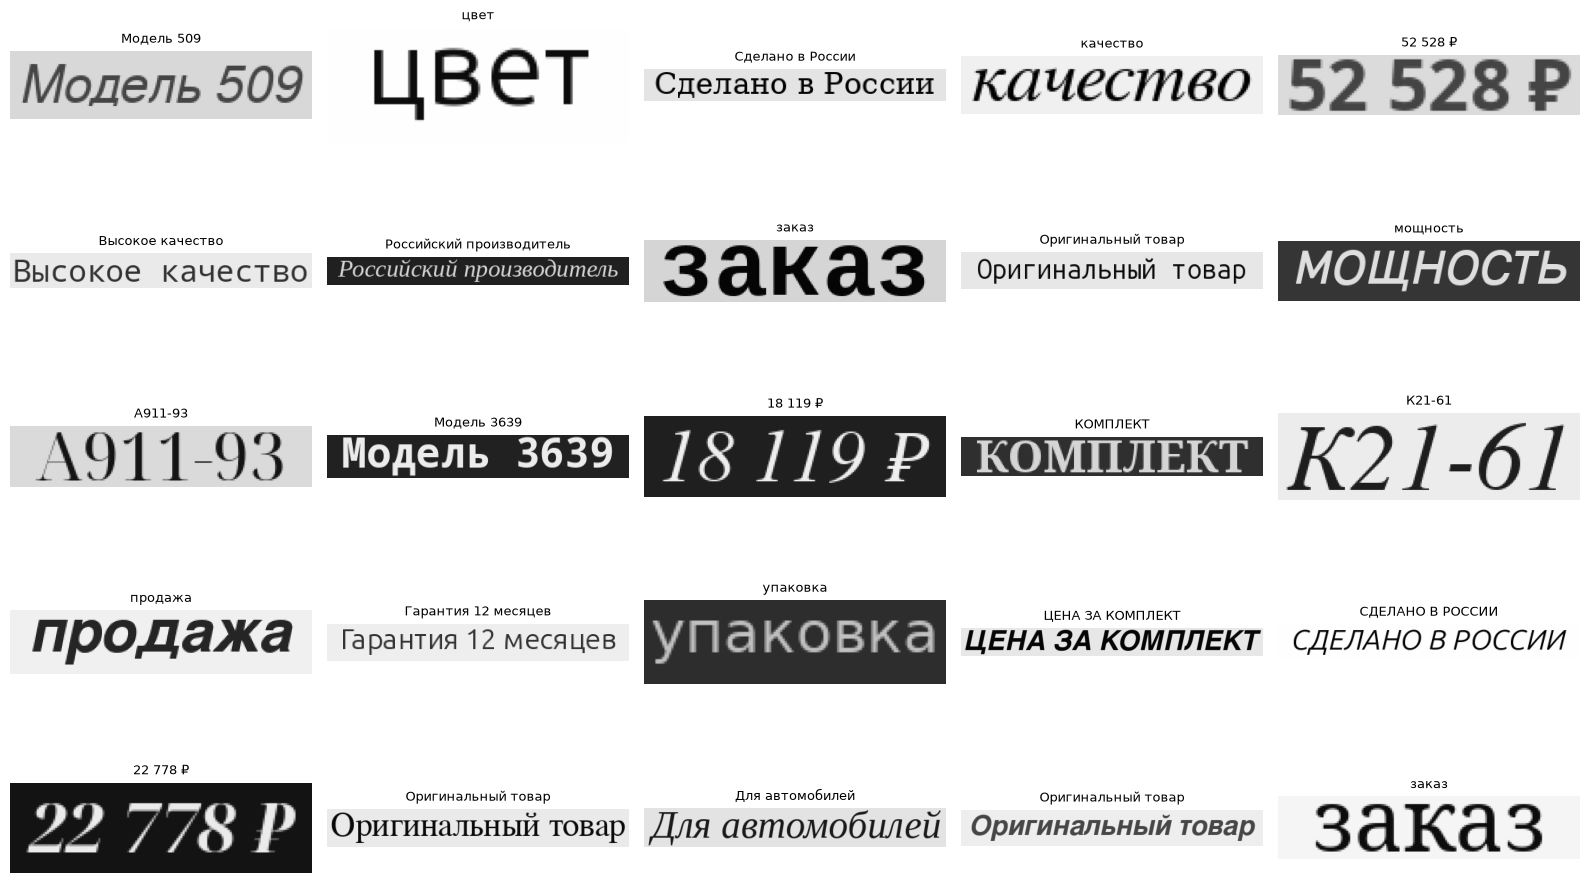

In [11]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(
    5,
    5,
    figsize=(16, 10),
)

for i, ax in enumerate(axes.flat):
    sample = synthetic[i]

    ax.imshow(sample["image"])
    ax.set_title(
        sample["text"],
        fontsize=9,
    )
    ax.axis("off")

plt.tight_layout()

In [21]:
from avito_orientation.dataset import OrientationDataset

synthetic_orientation = OrientationDataset(
    synthetic,
    train=True,
)

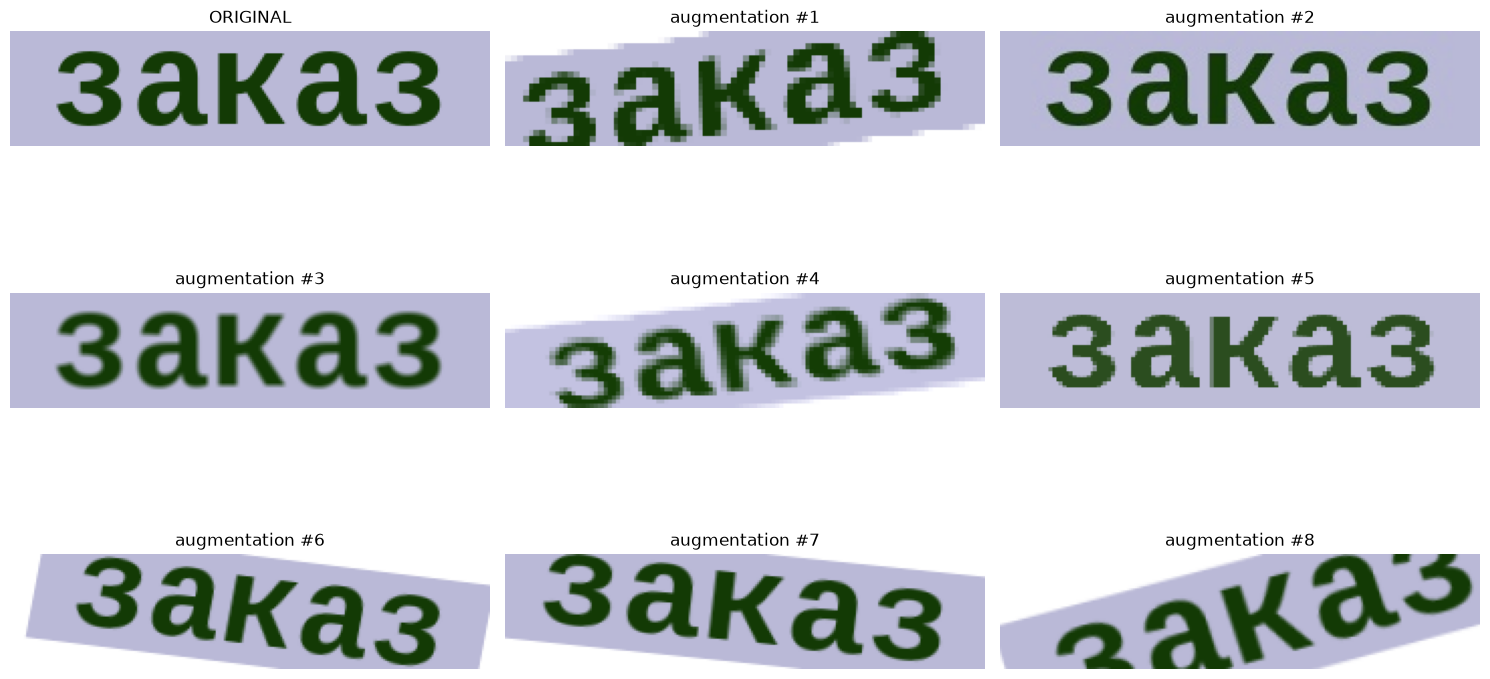

In [23]:
import matplotlib.pyplot as plt
import numpy as np


idx = 7
sample = synthetic[idx]

image = sample["image"]
image_np = np.array(image)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 9),
)

axes = axes.flat

axes[0].imshow(image)
axes[0].set_title("ORIGINAL")
axes[0].axis("off")

for i in range(1, 9):
    aug = train_data.augment(
        image=image_np,
    )["image"]

    axes[i].imshow(aug)
    axes[i].set_title(f"augmentation #{i}")
    axes[i].axis("off")

plt.tight_layout()

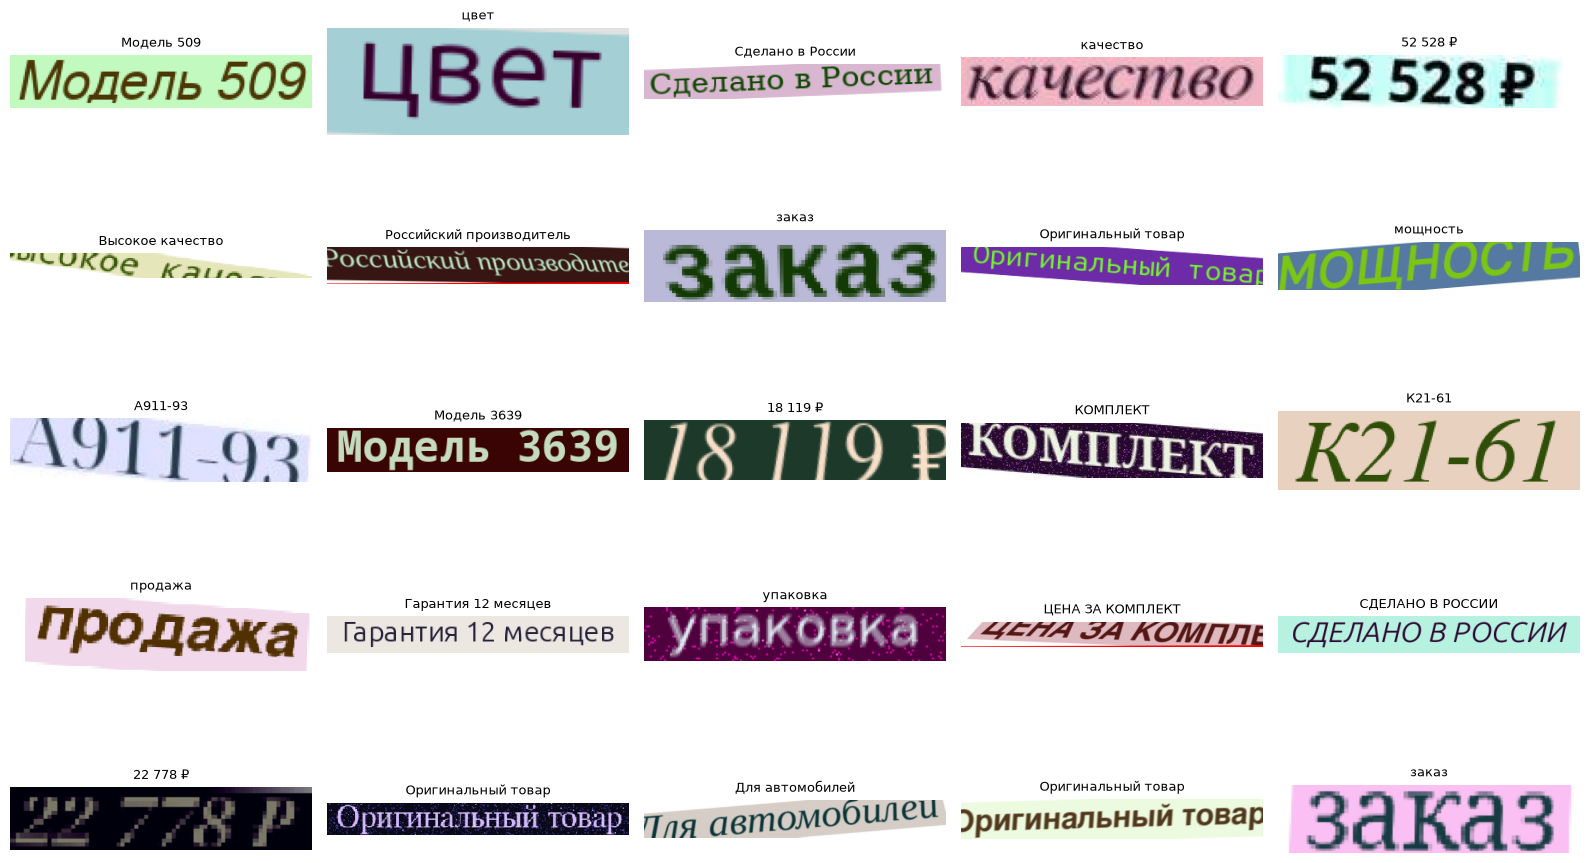

In [25]:
fig, axes = plt.subplots(
    5,
    5,
    figsize=(16, 10),
)

for i, ax in enumerate(axes.flat):
    sample = synthetic[i]
    image_np = np.array(sample["image"])

    aug = train_data.augment(
        image=image_np,
    )["image"]

    ax.imshow(aug)
    ax.set_title(
        sample["text"],
        fontsize=9,
    )
    ax.axis("off")

plt.tight_layout()

NameError: name 'train_loader' is not defined